**Customer Segmentation Project — Overview**

This notebook segments customers to identify actionable groups for targeted marketing. I followed a standard data-science workflow: load and validate data, derive interpretable features, perform exploratory analysis to surface patterns, preprocess and select features for clustering, determine an appropriate number of clusters, fit K‑Means, profile segments, and visualize results for business interpretation.

In [1]:
import pandas as pd 
import numpy as np 

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns 

**Data Loading**

Load the dataset and inspect a small sample to confirm field names, types, and representative records. This step ensures the schema matches expectations before deeper checks.

In [3]:
df = pd.read_csv('customer_segmentation.csv')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


**Data Quality Checks**

Run summary statistics, type checks, and missing-value counts to identify required cleaning steps and potential data issues that could bias analysis.

In [4]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='str')

In [5]:
df.shape

(2240, 29)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [7]:
df.isna().sum().sum()

np.int64(24)

In [8]:
df.dropna(inplace = True)

In [9]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,...,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.0,2216.0,2216.000000
mean,5588.353339,1968.820397,52247.251354,0.441787,0.505415,49.012635,305.091606,26.356047,166.995939,37.637635,...,5.319043,0.073556,0.074007,0.073105,0.064079,0.013538,0.009477,3.0,11.0,0.150271
std,3249.376275,11.985554,25173.076661,0.536896,0.544181,28.948352,337.327920,39.793917,224.283273,54.752082,...,2.425359,0.261106,0.261842,0.260367,0.244950,0.115588,0.096907,0.0,0.0,0.357417
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2814.750000,1959.000000,35303.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,174.500000,8.000000,68.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8421.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,505.000000,33.000000,232.250000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [10]:
df['Education'].value_counts()

Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64

In [11]:
df['Marital_Status'].value_counts()

Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [12]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst = True) 

In [13]:
df.info()

<class 'pandas.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2216 non-null   int64         
 1   Year_Birth           2216 non-null   int64         
 2   Education            2216 non-null   str           
 3   Marital_Status       2216 non-null   str           
 4   Income               2216 non-null   float64       
 5   Kidhome              2216 non-null   int64         
 6   Teenhome             2216 non-null   int64         
 7   Dt_Customer          2216 non-null   datetime64[us]
 8   Recency              2216 non-null   int64         
 9   MntWines             2216 non-null   int64         
 10  MntFruits            2216 non-null   int64         
 11  MntMeatProducts      2216 non-null   int64         
 12  MntFishProducts      2216 non-null   int64         
 13  MntSweetProducts     2216 non-null   int64       

**Feature Engineering**

Create interpretable features such as age, total children, aggregate spending, and customer tenure to capture lifetime value and behavior for segmentation. These derived variables improve the signal for downstream clustering and interpretation.

In [14]:
df['Age'] = 2026 - df['Year_Birth']
df['Age']

0       69
1       72
2       61
3       42
4       45
        ..
2235    59
2236    80
2237    45
2238    70
2239    72
Name: Age, Length: 2216, dtype: int64

In [15]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,0,0,0,0,3,11,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,0,0,0,0,3,11,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,0,0,0,0,0,3,11,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,0,0,0,0,0,3,11,0,42
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,0,0,0,0,0,3,11,0,45


In [16]:
df['Total_Children'] = df['Kidhome'] + df['Teenhome']
df['Total_Children']

0       0
1       2
2       0
3       1
4       1
       ..
2235    1
2236    3
2237    0
2238    1
2239    2
Name: Total_Children, Length: 2216, dtype: int64

In [17]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_Children'],
      dtype='str')

In [18]:
spend_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df['Total_Spending'] = df[spend_cols].sum(axis=1)
df[['Total_Spending']]

,Total_Spending
0,1617
1,27
2,776
3,53
4,422
...,...
2235,1341
2236,444
2237,1241
2238,843


In [19]:
df['Customer_Since'] = (pd.Timestamp('today') - df['Dt_Customer']).dt.days
df['Customer_Since'] 

0       5117
1       4567
2       4766
3       4593
4       4615
        ... 
2235    4835
2236    4473
2237    4609
2238    4610
2239    5076
Name: Customer_Since, Length: 2216, dtype: int64

**Exploratory Distributions**

Inspect marginal distributions (age, income, total spending) to understand central tendencies, skewness, and outliers that may require transformation or special handling during modeling.

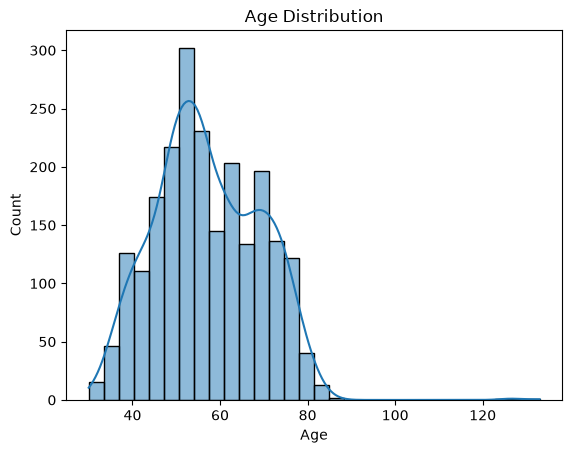

In [20]:
sns.histplot(df['Age'], bins = 30, kde=True)
plt.title('Age Distribution')
plt.show()

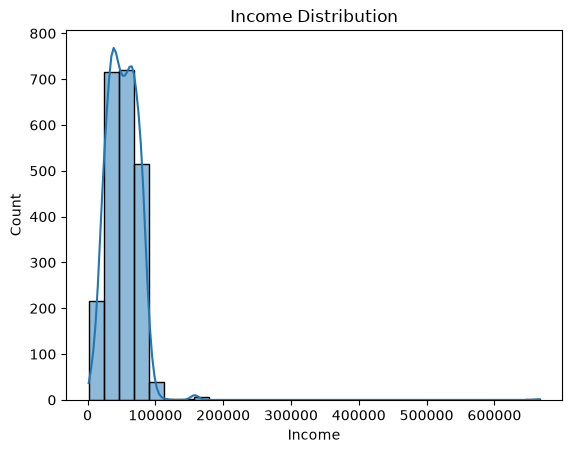

In [21]:
sns.histplot(df['Income'], bins = 30, kde=True)
plt.title('Income Distribution')
plt.show()

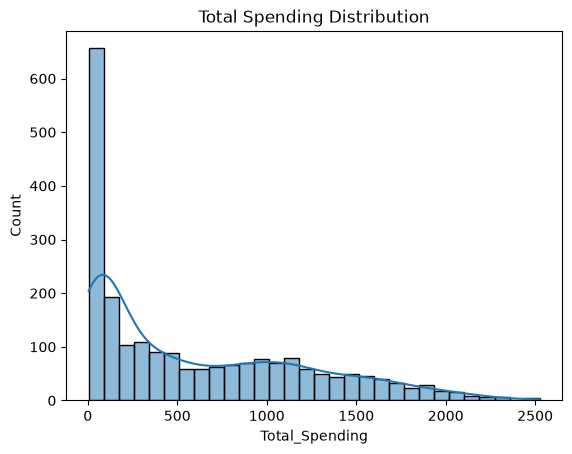

In [22]:
sns.histplot(df['Total_Spending'], bins = 30, kde=True)
plt.title('Total Spending Distribution')
plt.show()

**Segment Comparisons**

Use boxplots and group summaries to compare income and spending across demographic categories; this surfaces which groups differ meaningfully and guides feature emphasis in segmentation.

<function matplotlib.pyplot.show(close=None, block=None)>

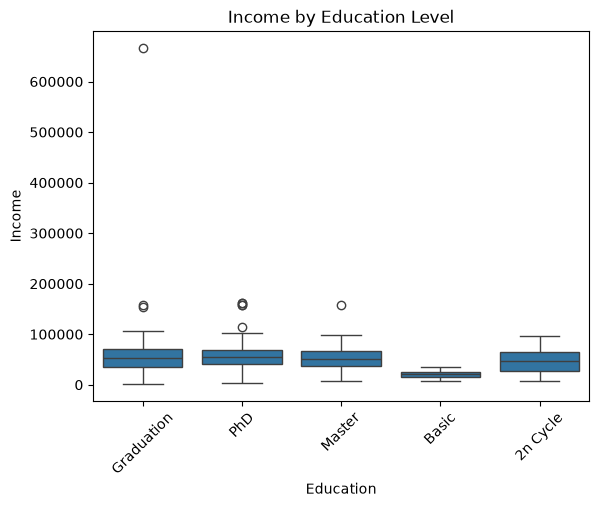

In [23]:
sns.boxplot(x='Education', y='Income', data= df)
plt.xticks(rotation = 45)
plt.title('Income by Education Level')
plt.show

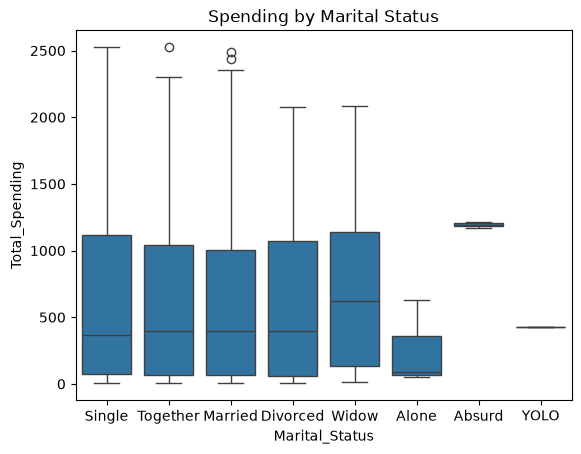

In [24]:
sns.boxplot(x='Marital_Status', y='Total_Spending', data= df)
plt.title('Spending by Marital Status')
plt.show()

**Relationships & Correlations**

Compute correlations and aggregated pivot tables to reveal linear associations and cross-tab patterns that inform feature selection and expectations for clusters.

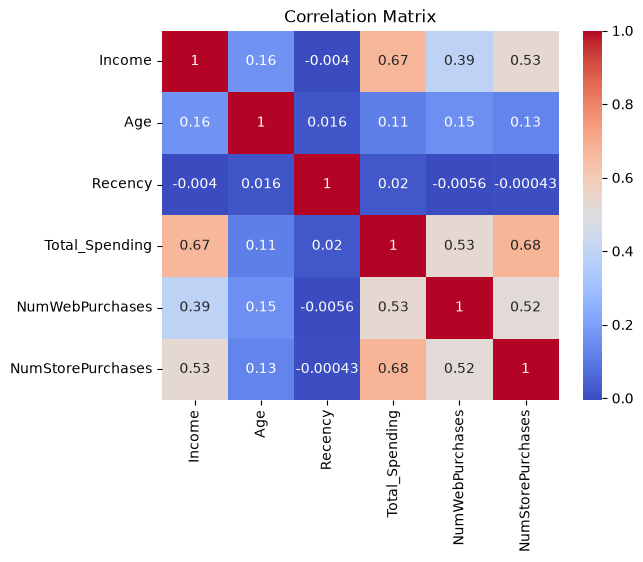

In [26]:
corr = df[['Income', 'Age', 'Recency', 'Total_Spending', 'NumWebPurchases', 'NumStorePurchases']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

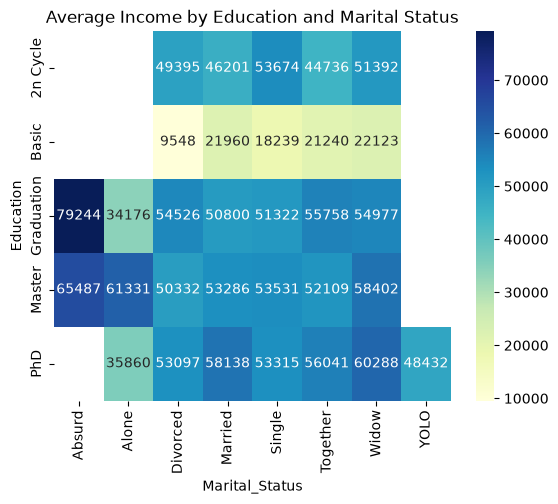

In [27]:
pivot_income = df.pivot_table(values = 'Income', index = 'Education', columns = 'Marital_Status', aggfunc = 'mean')
sns.heatmap(pivot_income, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Average Income by Education and Marital Status')
plt.show()

**Group-level Aggregations**

Aggregate metrics by demographic slices (education, marital status, age bins) to identify where marketing or product interventions could be targeted based on average behavior or response rates.

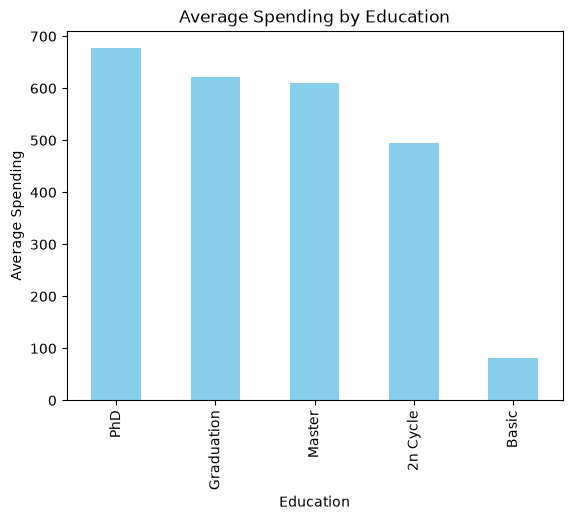

In [28]:
group1 = df.groupby('Education')['Total_Spending'].mean().sort_values(ascending=False)
group1.plot(kind='bar', color='skyblue')
plt.title('Average Spending by Education')
plt.xlabel('Education')
plt.ylabel('Average Spending')
plt.show()

In [35]:
df['AcceptedAny'] = df[['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']].sum(axis=1)
df['AcceptedAny'] = df['AcceptedAny'].apply(lambda x: 1 if x > 0 else 0)

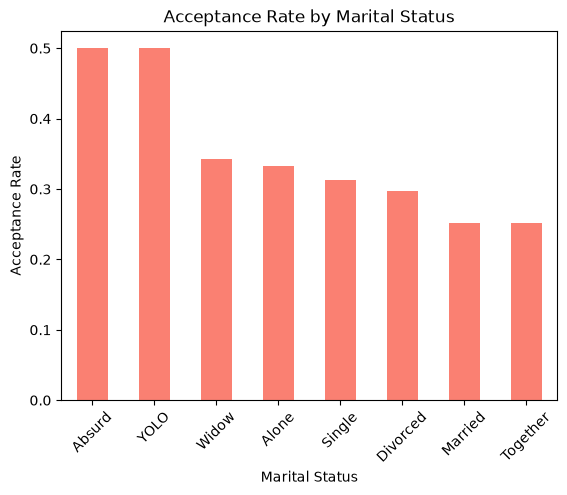

In [38]:
group2 = df.groupby('Marital_Status')['AcceptedAny'].mean().sort_values(ascending=False)
group2.plot(kind='bar', color='salmon')
plt.title('Acceptance Rate by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Acceptance Rate')
xticks = plt.xticks(rotation=45)
plt.show()

In [39]:
bins = [18, 30, 40, 50, 60, 70, 90]
labels = ['18-29', '30-39', '40-49', '50-59', '60-69', '70+']
group3 = df.groupby(pd.cut(df['Age'], bins=bins, labels=labels))['Income'].mean()

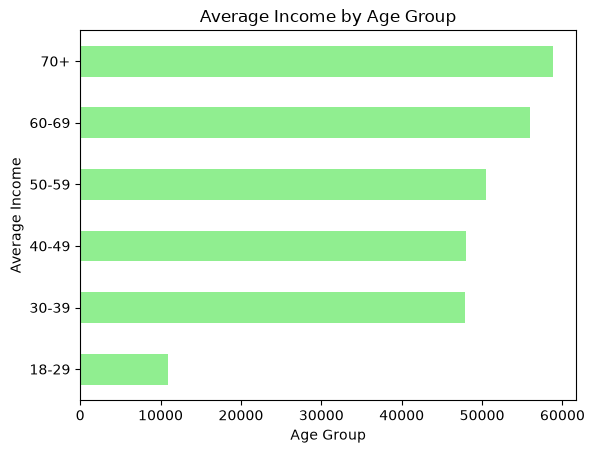

In [41]:
group3.plot(kind='barh', color='lightgreen')
plt.title('Average Income by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Income')
plt.show()

**Feature Selection for Clustering**

Choose variables that capture value and engagement (income, age, recency, total spending, web/store purchases). These features emphasize behavior and monetary value for meaningful segmentation.

In [42]:
features = ['Income', 'Age', 'Recency', 'Total_Spending', 'NumWebPurchases', 'NumStorePurchases']
X = df[features].copy()

**Scaling & Preprocessing Rationale**

Standardize continuous features so distance-based clustering does not unfairly weight variables with larger numeric ranges. This ensures compact and interpretable clusters.

In [44]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

**Clustering Approach**

We use K‑Means to partition customers into cohesive groups. Determine cluster count with diagnostic methods (elbow, silhouette) and validate clusters by stability and business interpretability.

In [45]:
X_scaled = scaler.fit_transform(X)
X_scaled

array([[ 0.2340627 ,  0.98644293,  0.31053212,  1.67548812,  1.42855332,
        -0.55414289],
       [-0.23455948,  1.23680074, -0.38050944, -0.96235832, -1.12588116,
        -1.16951781],
       [ 0.76947764,  0.31882209, -0.79513438,  0.28024985,  1.42855332,
         1.29198186],
       ...,
       [ 0.18809052, -1.01641959,  1.4507507 ,  1.05169551, -0.76096195,
         2.21504423],
       [ 0.67538765,  1.06989553, -1.41707178,  0.39140438,  0.6987149 ,
         1.29198186],
       [ 0.02470453,  1.23680074, -0.31140528, -0.7218    , -0.39604274,
        -0.55414289]], shape=(2216, 6))

In [46]:
from sklearn.cluster import KMeans

**Selecting Number of Clusters (Diagnostics)**

Compute WCSS across multiple K to identify diminishing returns in within-cluster variance (elbow). Complement with silhouette or business-driven constraints when necessary.

In [47]:
wcss = []
for i in range(2, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
wcss

[8545.283747315269,
 7684.526198022724,
 6867.845552059173,
 6256.528404799799,
 5803.80628081991,
 5452.631552119354,
 5201.144528222984,
 4943.058571329751]

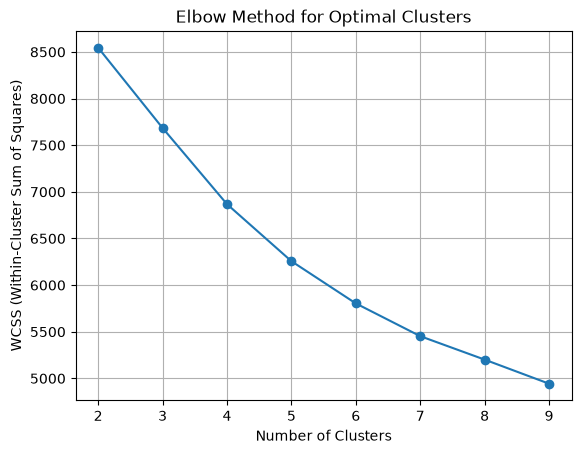

In [48]:
plt.plot(range(2, 10), wcss, marker='o')
plt.title('Elbow Method for Optimal Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.xticks(range(2, 10))
plt.grid()


**Fitting K‑Means & Assigning Labels**

Choose the selected K (from diagnostics) and fit K‑Means to the scaled data; attach cluster labels for downstream profiling and targeting.

In [51]:
kmeans = KMeans(n_clusters=6, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Children,Total_Spending,Customer_Since,AcceptedAny,Cluster
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,3,11,1,69,0,1617,5117,1,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,3,11,0,72,2,27,4567,0,3
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,3,11,0,61,0,776,4766,0,4
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,3,11,0,42,1,53,4593,0,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,3,11,0,45,1,422,4615,0,5


**Cluster Profiling — Interpret Centroids**

Summarize clusters using mean feature values and sizes to assign business-friendly labels (e.g., "High Value", "Occasional Low Spend"). Focus on patterns that suggest different marketing actions.

In [52]:
cluster_summary = df.groupby('Cluster')[features].mean()
cluster_summary

,Income,Age,Recency,Total_Spending,NumWebPurchases,NumStorePurchases
Cluster,,,,,,
0,32155.230599,50.031042,24.680710,94.689579,2.000000,3.106430
1,68966.478372,65.055980,74.862595,1155.888041,5.931298,8.491094
2,78595.632075,47.534591,41.154088,1388.122642,4.858491,9.056604
3,41936.469178,70.037671,55.794521,159.582192,2.465753,3.777397
4,61202.361039,63.387013,24.423377,801.849351,6.755844,7.340260
5,35470.305040,49.358090,77.660477,136.809019,2.530504,3.469496


In [53]:
df['Cluster'].value_counts()

Cluster
0    451
1    393
4    385
5    377
2    318
3    292
Name: count, dtype: int64

**Visualization with PCA**

Reduce to two principal components purely for visualization to inspect cluster separation and overlap; use plots qualitatively to validate interpretability and guide further analysis.

In [55]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)
df['PCA1'], df['PCA2'] = pca_data[:, 0], pca_data[:,1]

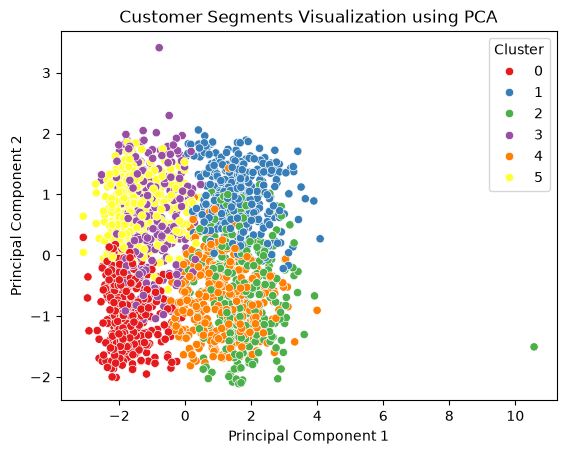

In [56]:
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df, palette='Set1')
plt.title('Customer Segments Visualization using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

**Persisting Artifacts**

Save the trained scaler and clustering model for reuse in scoring pipelines, A/B tests, or production scoring so downstream systems can reproduce segment labels consistently.

In [59]:
import joblib

joblib.dump(kmeans, 'kmeans_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']